# MoE Ablation Dashboard

Compares GPS++ with and without Mixture of Experts (MoE) at the same model scale (768d, 8 layers).

**Three conditions:**
- **Scratch (768d/8L)**: No pre-training, no MoE — same architecture baseline
- **MoE FT (toymix_dti)**: Pre-trained with MoE (4 experts, top-2) on toymix_dti, then finetuned
- **GPS++ 800M best**: Best result from the full-scale 800M model (for reference)

5 representative ADMET tasks: one per category (A/D/M/E/T).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

df = pd.read_csv('../results/experiment_results.csv')
print(f'Loaded {len(df)} rows')

Loaded 997 rows


In [2]:
# Task definitions
TASKS = {
    'caco2_wang':      ('graph_caco2_wang/mae/test', 'lower', 'Absorption', 'MAE'),
    'bbb_martins':     ('graph_bbb_martins/auroc/test', 'higher', 'Distribution', 'AUROC'),
    'cyp3a4_veith':    ('graph_cyp3a4_veith/auprc/test', 'higher', 'Metabolism', 'AUPRC'),
    'half_life_obach': ('graph_half_life_obach/spearman/test', 'higher', 'Excretion', 'Spearman'),
    'herg':            ('graph_herg/auroc/test', 'higher', 'Toxicity', 'AUROC'),
}

TDC_SOTA = {
    'caco2_wang':      (0.256, 0.006),
    'bbb_martins':     (0.924, 0.003),
    'cyp3a4_veith':    (0.916, 0.000),
    'half_life_obach': (0.576, 0.025),
    'herg':            (0.880, 0.002),
}

TASK_ORDER = list(TASKS.keys())

In [3]:
# Extract results for each condition
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

def get_latest(subset, task, col):
    """Get the latest result for a task from a subset."""
    rows = subset[subset['task'] == task].sort_values('timestamp')
    vals = pd.to_numeric(rows[col], errors='coerce').dropna()
    return vals.iloc[-1] if len(vals) > 0 else np.nan

def get_best(subset, task, col, direction):
    """Get the best result for a task from a subset."""
    rows = subset[subset['task'] == task]
    vals = pd.to_numeric(rows[col], errors='coerce').dropna()
    if len(vals) == 0:
        return np.nan
    return vals.min() if direction == 'lower' else vals.max()

# Conditions
moe_ft = df[df['wandb_tags'].str.contains('moe.*finetune', case=False, na=False)]
scratch_768 = df[df['wandb_tags'].str.contains('moe_baseline.*768d8L', case=False, na=False)]
gpspp_800M_ft = df[
    (df['hidden_dim'] == 1536) & (df['gnn_depth'] == 12) &
    (df['is_finetuning'] == True)
]

print(f'MoE FT rows: {len(moe_ft)}')
print(f'Scratch 768d/8L rows: {len(scratch_768)}')
print(f'GPS++ 800M FT rows: {len(gpspp_800M_ft)}')

MoE FT rows: 6
Scratch 768d/8L rows: 5
GPS++ 800M FT rows: 475


## Results Table

In [4]:
# Build results table
rows = []
for task in TASK_ORDER:
    col, direction, category, metric_name = TASKS[task]
    arrow = '\u2191' if direction == 'higher' else '\u2193'
    sota_mean, sota_std = TDC_SOTA[task]

    scratch_v = get_latest(scratch_768, task, col)
    moe_v = get_latest(moe_ft, task, col)
    g800_v = get_best(gpspp_800M_ft, task, col, direction)

    rows.append({
        'Task': task,
        'Category': category,
        f'Metric ({arrow})': metric_name,
        'TDC SOTA': f'{sota_mean:.3f} \u00b1 {sota_std:.3f}',
        'Scratch (768d/8L)': scratch_v,
        'MoE FT (768d/8L)': moe_v,
        'GPS++ 800M best': g800_v,
    })

results = pd.DataFrame(rows).set_index('Task')

# Style: bold best among Scratch and MoE (the controlled comparison)
def highlight_moe_comparison(row):
    styles = [''] * len(row)
    task = row.name
    _, direction, _, _ = TASKS[task]
    s_col = 'Scratch (768d/8L)'
    m_col = 'MoE FT (768d/8L)'

    s_idx = list(results.columns).index(s_col)
    m_idx = list(results.columns).index(m_col)

    s_val = row[s_col]
    m_val = row[m_col]

    if pd.notna(s_val) and pd.notna(m_val):
        if direction == 'lower':
            winner = s_idx if s_val < m_val else m_idx
        else:
            winner = s_idx if s_val > m_val else m_idx
        styles[winner] = 'font-weight: bold; color: #1a5fb4'
    elif pd.notna(m_val):
        styles[m_idx] = 'font-weight: bold; color: #1a5fb4'
    elif pd.notna(s_val):
        styles[s_idx] = 'font-weight: bold; color: #1a5fb4'

    return styles

styled = (
    results.style
    .format(precision=4, na_rep='(pending)',
            subset=['Scratch (768d/8L)', 'MoE FT (768d/8L)', 'GPS++ 800M best'])
    .apply(highlight_moe_comparison, axis=1)
    .set_caption('MoE Ablation: Same architecture (768d/8L), with vs without MoE pre-training')
    .set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
    ])
)

print('Blue = winner of Scratch vs MoE (controlled comparison)')
print('GPS++ 800M shown for reference (different model scale)')
display(styled)

Blue = winner of Scratch vs MoE (controlled comparison)
GPS++ 800M shown for reference (different model scale)


,Category,Metric (↓),TDC SOTA,Scratch (768d/8L),MoE FT (768d/8L),GPS++ 800M best,Metric (↑)
Task,,,,,,,
caco2_wang,Absorption,MAE,0.256 ± 0.006,0.8566,0.4294,0.3611,nan
bbb_martins,Distribution,nan,0.924 ± 0.003,0.7162,0.7750,0.8485,AUROC
cyp3a4_veith,Metabolism,nan,0.916 ± 0.000,0.4386,0.7388,0.8052,AUPRC
half_life_obach,Excretion,nan,0.576 ± 0.025,0.1704,0.3013,0.4972,Spearman
herg,Toxicity,nan,0.880 ± 0.002,0.7392,0.7802,0.8021,AUROC


## Per-task bar chart

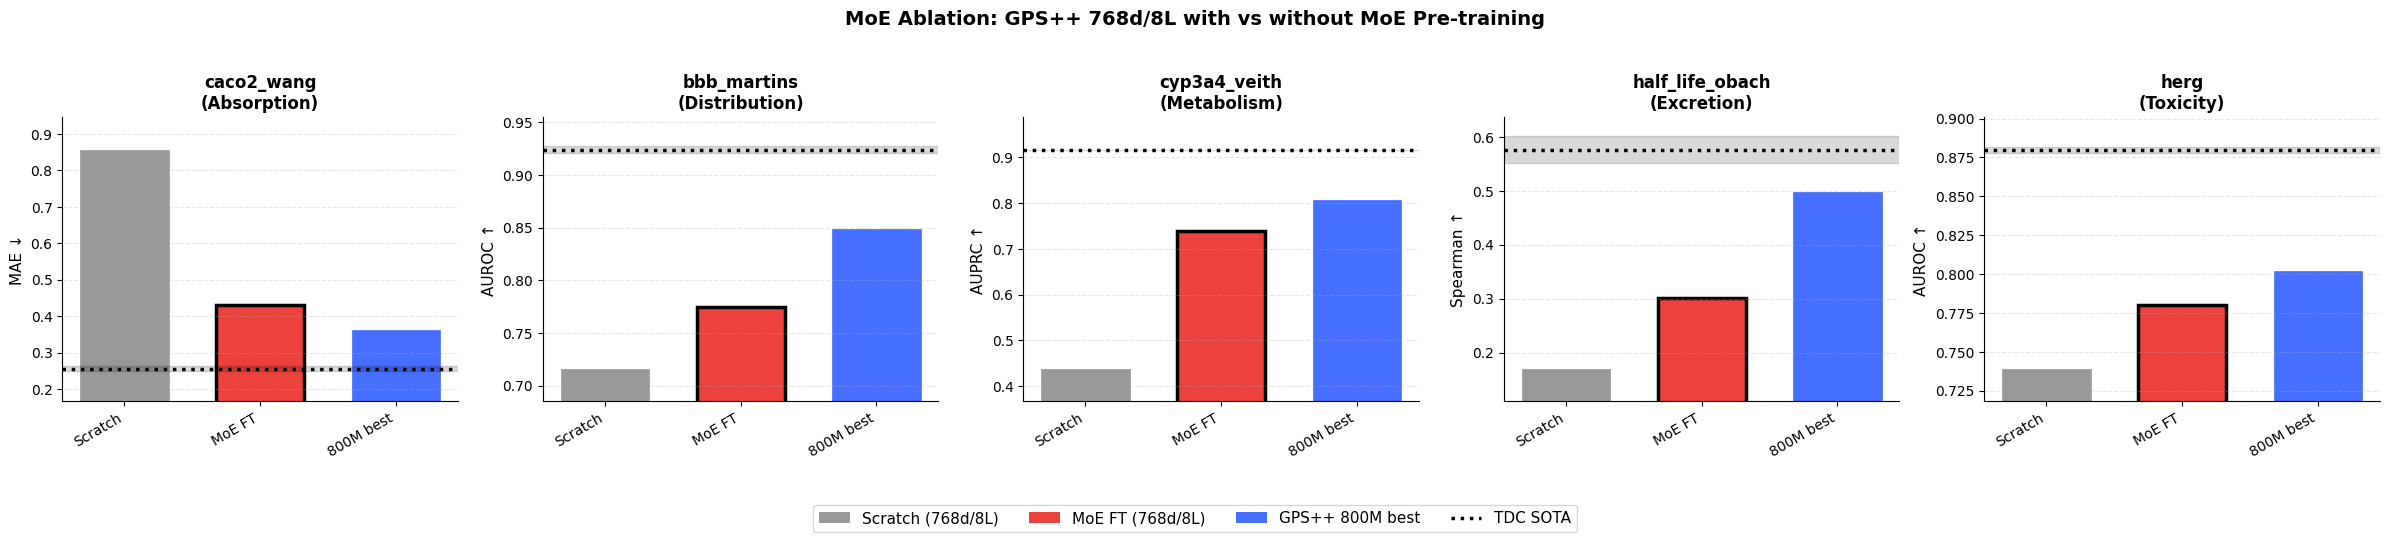

In [5]:
conditions = ['Scratch (768d/8L)', 'MoE FT (768d/8L)', 'GPS++ 800M best']
cond_colors = ['#999999', '#EB423D', '#466eff']

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for ax, task in zip(axes, TASK_ORDER):
    col, direction, category, metric_name = TASKS[task]
    arrow = '\u2191' if direction == 'higher' else '\u2193'
    sota_mean, sota_std = TDC_SOTA[task]

    vals = [results.loc[task, c] for c in conditions]

    # Find best among scratch and MoE
    controlled = [vals[0], vals[1]]
    controlled_finite = [(i, v) for i, v in enumerate(controlled) if pd.notna(v)]
    best_controlled = None
    if len(controlled_finite) >= 2:
        if direction == 'lower':
            best_controlled = min(controlled_finite, key=lambda x: x[1])[0]
        else:
            best_controlled = max(controlled_finite, key=lambda x: x[1])[0]

    for i, (v, c) in enumerate(zip(vals, cond_colors)):
        if pd.notna(v):
            ec = 'black' if i == best_controlled else c
            lw = 2.5 if i == best_controlled else 0.5
            ax.bar(i, v, color=c, edgecolor=ec, linewidth=lw, width=0.65)

    # SOTA line
    ax.axhline(y=sota_mean, color='black', linewidth=2.5, linestyle=':', zorder=5)
    ax.axhspan(sota_mean - sota_std, sota_mean + sota_std,
               alpha=0.15, color='black', zorder=1)

    # Y-axis limits: zoom to data range
    all_v = [v for v in vals if pd.notna(v)] + [sota_mean]
    vmin, vmax = min(all_v), max(all_v)
    span = vmax - vmin if vmax > vmin else vmax * 0.1
    ax.set_ylim(max(0, vmin - span * 0.15), vmax + span * 0.15)

    ax.set_xticks(range(3))
    ax.set_xticklabels(['Scratch', 'MoE FT', '800M best'], rotation=30, ha='right', fontsize=10)
    ax.set_title(f'{task}\n({category})', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric_name} {arrow}', fontsize=11)
    ax.tick_params(axis='y', labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', ls='--', alpha=0.3)

# Legend
legend_handles = [Patch(facecolor=c, label=l) for c, l in zip(cond_colors, conditions)]
legend_handles.append(Line2D([0], [0], color='black', linewidth=2.5, linestyle=':', label='TDC SOTA'))
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=11,
           bbox_to_anchor=(0.5, -0.08), frameon=True)

fig.suptitle('MoE Ablation: GPS++ 768d/8L with vs without MoE Pre-training',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

## Summary

In [6]:
# Count wins: MoE vs Scratch (controlled comparison)
moe_wins = 0
scratch_wins = 0
ties = 0
pending = 0

print(f'{"Task":<25s} {"Scratch":>10s} {"MoE FT":>10s} {"Winner":>15s} {"Delta":>10s}')
print('=' * 75)

for task in TASK_ORDER:
    col, direction, category, metric_name = TASKS[task]
    s_v = results.loc[task, 'Scratch (768d/8L)']
    m_v = results.loc[task, 'MoE FT (768d/8L)']

    if pd.isna(s_v) or pd.isna(m_v):
        winner = '(pending)'
        delta_str = ''
        pending += 1
    else:
        if direction == 'lower':
            delta = s_v - m_v  # positive = MoE better
        else:
            delta = m_v - s_v  # positive = MoE better

        if abs(delta) < 1e-6:
            winner = 'tie'
            ties += 1
        elif delta > 0:
            winner = 'MoE'
            moe_wins += 1
        else:
            winner = 'Scratch'
            scratch_wins += 1
        delta_str = f'{delta:+.4f}'

    s_str = f'{s_v:.4f}' if pd.notna(s_v) else '(pending)'
    m_str = f'{m_v:.4f}' if pd.notna(m_v) else '(pending)'
    print(f'{task:<25s} {s_str:>10s} {m_str:>10s} {winner:>15s} {delta_str:>10s}')

print()
total = moe_wins + scratch_wins + ties
print(f'MoE wins: {moe_wins}/{total}  |  Scratch wins: {scratch_wins}/{total}  |  Ties: {ties}/{total}')
if pending > 0:
    print(f'Pending: {pending} tasks (run scripts/05_scratch_moe_baseline.sh)')

Task                         Scratch     MoE FT          Winner      Delta
caco2_wang                    0.8566     0.4294             MoE    +0.4272
bbb_martins                   0.7162     0.7750             MoE    +0.0588
cyp3a4_veith                  0.4386     0.7388             MoE    +0.3002
half_life_obach               0.1704     0.3013             MoE    +0.1309
herg                          0.7392     0.7802             MoE    +0.0411

MoE wins: 5/5  |  Scratch wins: 0/5  |  Ties: 0/5
